In [ ]:
import os

import torch
import matplotlib.pyplot as plt

from model import DiffusionUNet
from diffusion import Diffusion

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_size = 64

In [ ]:
model = DiffusionUNet().to(device)
model.load_state_dict(torch.load('../saved_models/best_diffusion_model.pth',map_location=device))
model.eval()
print('model loaded..')

model loaded..


In [4]:
diffusion = Diffusion(device=device)

generating four images...

In [8]:
generated_images = diffusion.sample(model=model,num_images=4, image_size=image_size, device=device)

In [9]:
print('shape :', generated_images.shape)
print('min :', generated_images.min().item())
print('max :', generated_images.max().item())
print('mean :', generated_images.mean().item())
print('std :', generated_images.std().item())

shape : torch.Size([4, 3, 64, 64])
min : 0.0
max : 1.0
mean : 0.7929952144622803
std : 0.35883766412734985


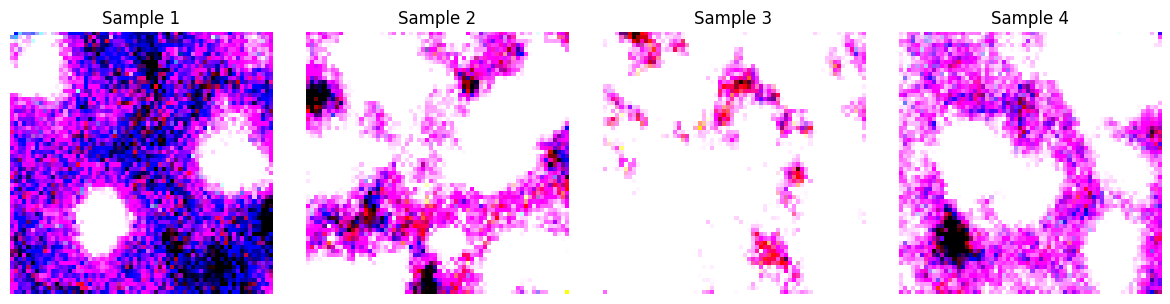

In [10]:
fig, axes = plt.subplots(1,4,figsize=(12,3))

for i in range(4):

    image = generated_images[i]
    image = image.permute(1,2,0).cpu()
    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}')

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('../outputs/generated',exist_ok=True)

for i in range(4):

    image = generated_images[i]
    image = image.permute(1,2,0).cpu().numpy()

    plt.imsave(f'../outputs/generated/sample_{i+1}.png', image)

reverse diffusion visualization...

In [12]:
generated_image, reverse_steps = diffusion.sample(model=model,num_images=1,image_size=image_size,device=device, save_steps=True)

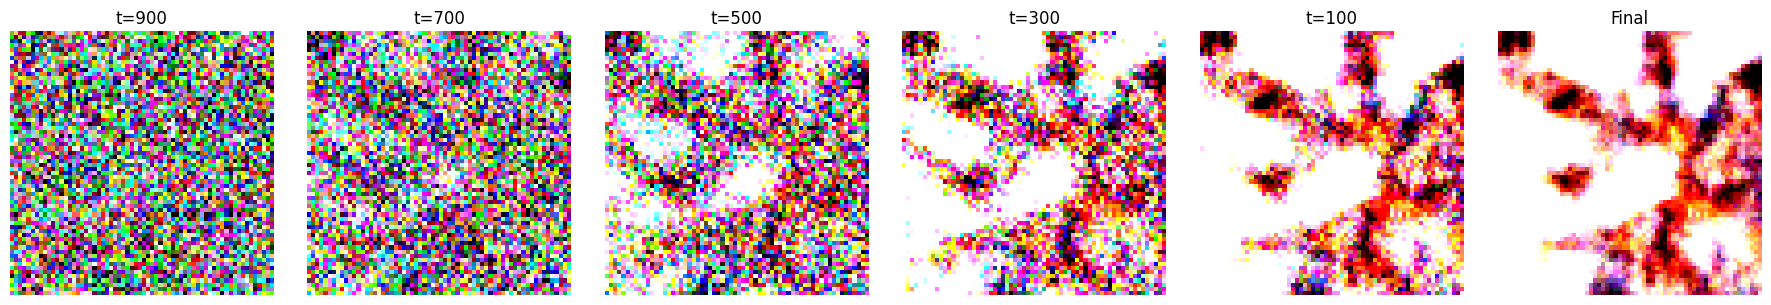

In [ ]:
fig, axes = plt.subplots(1,len(reverse_steps), figsize=(18,3))

titles = ['t=900','t=700','t=500', 't=300','t=100','Final']

for i, image in enumerate(reverse_steps):

    image = image[0].permute(1,2,0)
    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(titles[i])

plt.tight_layout()

os.makedirs('../outputs/checkpoints_visualization',exist_ok=True)
plt.savefig('../outputs/checkpoints_visualization/reverse_process.png', dpi=300, bbox_inches='tight')

plt.show()

to check if the model learned to predict the noise?, or not?,..

In [ ]:
from dataset import create_dataloader

selected_classes = ['Cat', 'Lion', 'Tiger','Horse', 'Elephant']

loader = create_dataloader(dataset_path='animal_data', selected_classes=selected_classes, 
                           batch_size=1,image_size=64,images_per_class=20)

image, _ = next(iter(loader))
image = image.to(device)

In [38]:
timestep = torch.tensor([500]).to(device)
noisy_image, true_noise = diffusion.add_noise(image, timestep)

In [39]:
model.eval()

with torch.no_grad():

    predicted_noise = model(noisy_image, timestep)

In [40]:
alpha_hat = diffusion.alpha_hat[timestep][:, None,None, None]

reconstructed = (noisy_image - torch.sqrt(1 - alpha_hat) * predicted_noise) / torch.sqrt(alpha_hat)
reconstructed = reconstructed.clamp(-1, 1)
reconstructed = (reconstructed + 1) / 2

In [41]:
original = (image.squeeze(0).cpu() + 1) / 2
original = original.permute(1, 2, 0)

noisy = (noisy_image.squeeze(0).cpu() + 1) / 2
noisy = noisy.permute(1, 2, 0)

reconstructed = reconstructed.squeeze(0).cpu()
reconstructed = reconstructed.permute(1, 2, 0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6332805..2.3283815].


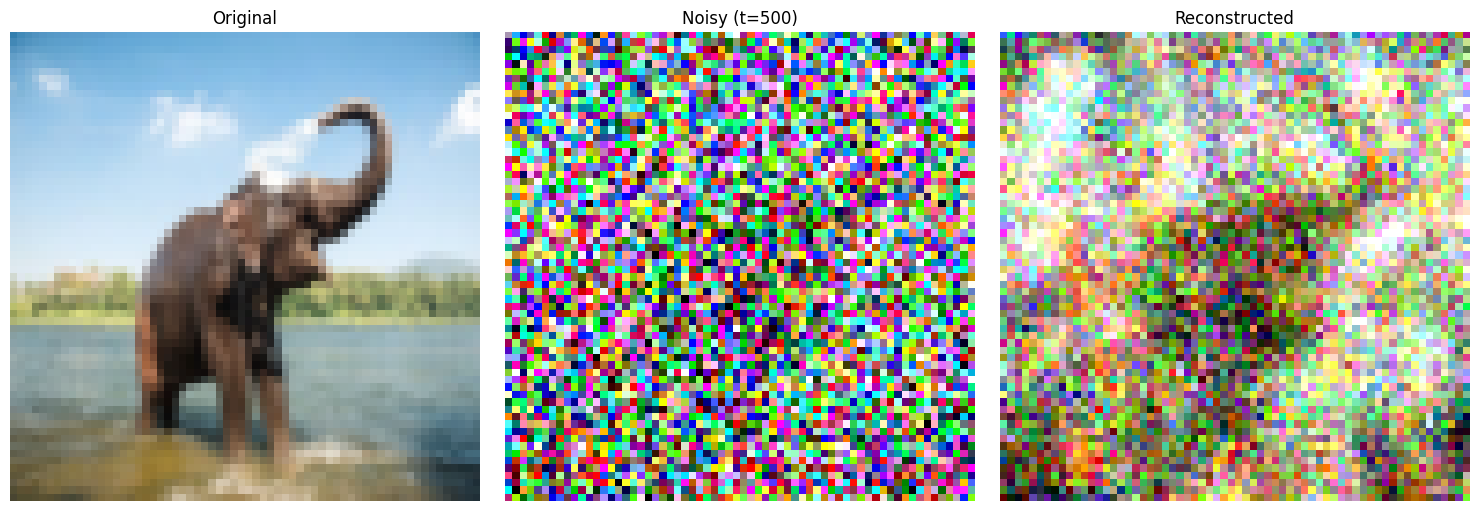

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title('Noisy (t=500)')
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(reconstructed)
plt.title('Reconstructed')
plt.axis('off')

plt.tight_layout()
plt.show()